# Set-to-Set Stat Drift Analysis
Do player stats differ between sets? Measures mean deltas (set2−set1, set3−set2) split by surface and whether the player won the previous set.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../atp/data/atp.db")
set_stats = pd.read_sql("SELECT * FROM set_stats", conn)
matches = pd.read_sql("SELECT year, event_id, match_code, surface FROM matches", conn)
print(f"set_stats: {len(set_stats):,} rows")
print(set_stats.set_number.value_counts().sort_index())

set_stats: 6,532 rows
set_number
1    2782
2    2772
3     978
Name: count, dtype: int64


In [2]:
STAT_COLS = [
    "first_serve_pct",
    "first_serve_won_pct",
    "second_serve_won_pct",
    "first_return_won_pct",
    "second_return_won_pct",
    "bp_saved_pct",
    "bp_converted_pct",
    "total_svc_pts_won_pct",
    "total_ret_pts_won_pct",
]

MATCH_KEY = ["year", "event_id", "match_code", "player_id"]
SET_KEY   = ["year", "event_id", "match_code"]

# ── build set-winner tag ──────────────────────────────────────────────────────
opp = (
    set_stats[["year","event_id","match_code","player_id","set_number","set_score"]]
    .rename(columns={"player_id": "opp_id", "set_score": "opp_score"})
)
tagged = set_stats.merge(opp, on=["year","event_id","match_code","set_number"])
tagged = tagged[tagged.player_id != tagged.opp_id].copy()
# set_score is games won; tiebreak sets can be 7 vs 6 — cast safely
tagged["won_set"] = pd.to_numeric(tagged.set_score, errors="coerce") > pd.to_numeric(tagged.opp_score, errors="coerce")

print(f"tagged rows: {len(tagged):,}  (should equal set_stats rows = {len(set_stats):,})")

tagged rows: 6,532  (should equal set_stats rows = 6,532)


In [3]:
def build_transitions(from_set, to_set, tagged, matches):
    """Compute per-player stat deltas between two consecutive sets."""
    prev = tagged[tagged.set_number == from_set][MATCH_KEY + STAT_COLS + ["won_set"]].copy()
    curr = tagged[tagged.set_number == to_set][MATCH_KEY + STAT_COLS].copy()

    prev = prev.rename(columns={c: f"prev_{c}" for c in STAT_COLS} | {"won_set": "won_prev_set"})
    curr = curr.rename(columns={c: f"curr_{c}" for c in STAT_COLS})

    df = prev.merge(curr, on=MATCH_KEY)
    df = df.merge(matches, on=["year","event_id","match_code"], how="left")

    for c in STAT_COLS:
        df[f"d_{c}"] = df[f"curr_{c}"] - df[f"prev_{c}"]

    df["transition"] = f"{from_set}→{to_set}"
    return df

t12 = build_transitions(1, 2, tagged, matches)
t23 = build_transitions(2, 3, tagged, matches)
transitions = pd.concat([t12, t23], ignore_index=True)

DELTA_COLS = [f"d_{c}" for c in STAT_COLS]

print(f"1→2 transitions: {len(t12):,}")
print(f"2→3 transitions: {len(t23):,}")

1→2 transitions: 2,772
2→3 transitions: 978


In [4]:
def summarise(df, group_cols=None):
    """Mean ± std of each delta col, with t-test p-value vs 0."""
    def agg(g):
        rows = {}
        for c in DELTA_COLS:
            vals = g[c].dropna()
            mean = vals.mean()
            std  = vals.std()
            _, p = stats.ttest_1samp(vals, 0)
            rows[c] = f"{mean:+.2f} ± {std:.2f}  (p={p:.3f})"
        rows["n"] = len(g)
        return pd.Series(rows)

    if group_cols:
        return df.groupby(group_cols).apply(agg)
    else:
        return agg(df).to_frame("overall").T

nice = [c.replace("d_","") for c in DELTA_COLS]

def pretty(df):
    df = df.copy()
    df.columns = [c.replace("d_","") if c in DELTA_COLS else c for c in df.columns]
    return df

In [5]:
# ── Overall ───────────────────────────────────────────────────────────────────
print("=== Overall (all transitions combined) ===")
display(pretty(summarise(transitions)))

=== Overall (all transitions combined) ===


,first_serve_pct,first_serve_won_pct,seconserve_won_pct,first_return_won_pct,seconreturn_won_pct,bp_savepct,bp_convertepct,total_svc_pts_won_pct,total_ret_pts_won_pct,n
overall,+0.04 ± 13.13 (p=0.847),-0.60 ± 16.88 (p=0.031),+0.01 ± 24.26 (p=0.984),+0.25 ± 16.39 (p=0.347),-0.38 ± 24.22 (p=0.340),-0.53 ± 54.36 (p=0.554),-0.33 ± 49.60 (p=0.685),-0.34 ± 14.87 (p=0.163),-0.01 ± 14.52 (p=0.966),3750


In [6]:
# ── By transition ─────────────────────────────────────────────────────────────
print("=== By transition (1→2 vs 2→3) ===")
display(pretty(summarise(transitions, "transition")))

=== By transition (1→2 vs 2→3) ===


,first_serve_pct,first_serve_won_pct,seconserve_won_pct,first_return_won_pct,seconreturn_won_pct,bp_savepct,bp_convertepct,total_svc_pts_won_pct,total_ret_pts_won_pct,n
transition,,,,,,,,,,
1→2,+0.12 ± 13.02 (p=0.620),-0.65 ± 16.80 (p=0.041),-0.10 ± 24.12 (p=0.835),+0.40 ± 16.47 (p=0.196),-0.19 ± 24.12 (p=0.680),+0.36 ± 54.34 (p=0.730),+0.00 ± 48.86 (p=0.997),-0.39 ± 14.61 (p=0.161),+0.13 ± 14.38 (p=0.626),2772
2→3,-0.19 ± 13.45 (p=0.660),-0.43 ± 17.10 (p=0.430),+0.30 ± 24.67 (p=0.703),-0.18 ± 16.18 (p=0.725),-0.91 ± 24.52 (p=0.245),-3.02 ± 54.39 (p=0.082),-1.27 ± 51.66 (p=0.442),-0.20 ± 15.60 (p=0.694),-0.42 ± 14.91 (p=0.383),978


In [7]:
# ── By surface ────────────────────────────────────────────────────────────────
print("=== By surface ===")
display(pretty(summarise(transitions, "surface")))

=== By surface ===


,first_serve_pct,first_serve_won_pct,seconserve_won_pct,first_return_won_pct,seconreturn_won_pct,bp_savepct,bp_convertepct,total_svc_pts_won_pct,total_ret_pts_won_pct,n
surface,,,,,,,,,,
Clay,-0.06 ± 13.09 (p=0.844),-0.43 ± 17.65 (p=0.288),-0.14 ± 24.40 (p=0.805),+0.01 ± 17.16 (p=0.975),-0.27 ± 24.37 (p=0.622),-1.32 ± 52.81 (p=0.271),-0.39 ± 49.58 (p=0.730),-0.30 ± 15.39 (p=0.392),-0.12 ± 15.04 (p=0.735),1930
Hard,+0.15 ± 13.18 (p=0.634),-0.77 ± 16.01 (p=0.040),+0.16 ± 24.12 (p=0.775),+0.51 ± 15.54 (p=0.165),-0.49 ± 24.08 (p=0.387),+0.32 ± 55.96 (p=0.807),-0.26 ± 49.63 (p=0.821),-0.38 ± 14.30 (p=0.257),+0.10 ± 13.95 (p=0.755),1820


In [8]:
# ── By won_prev_set ───────────────────────────────────────────────────────────
print("=== By won_prev_set (momentum) ===")
display(pretty(summarise(transitions, "won_prev_set")))

=== By won_prev_set (momentum) ===


,first_serve_pct,first_serve_won_pct,seconserve_won_pct,first_return_won_pct,seconreturn_won_pct,bp_savepct,bp_convertepct,total_svc_pts_won_pct,total_ret_pts_won_pct,n
won_prev_set,,,,,,,,,,
False,+1.33 ± 13.23 (p=0.000),+2.73 ± 17.38 (p=0.000),+4.89 ± 22.88 (p=0.000),+3.55 ± 14.96 (p=0.000),+4.45 ± 24.47 (p=0.000),+2.56 ± 48.35 (p=0.022),+12.36 ± 47.73 (p=0.000),+3.81 ± 14.54 (p=0.000),+4.12 ± 13.45 (p=0.000),1875
True,-1.24 ± 12.91 (p=0.000),-3.92 ± 15.68 (p=0.000),-4.87 ± 24.62 (p=0.000),-3.05 ± 17.09 (p=0.000),-5.20 ± 22.99 (p=0.000),-3.61 ± 59.63 (p=0.009),-13.02 ± 48.18 (p=0.000),-4.48 ± 14.01 (p=0.000),-4.14 ± 14.38 (p=0.000),1875


In [9]:
# ── By transition × won_prev_set ──────────────────────────────────────────────
print("=== By transition × won_prev_set ===")
display(pretty(summarise(transitions, ["transition", "won_prev_set"])))

=== By transition × won_prev_set ===


first_serve_pct       first_serve_won_pct  \
transition won_prev_set                                                       
1→2        False         +1.23 ± 13.06  (p=0.000)  +2.35 ± 17.40  (p=0.000)   
           True          -0.99 ± 12.89  (p=0.004)  -3.66 ± 15.61  (p=0.000)   
2→3        False         +1.59 ± 13.71  (p=0.011)  +3.79 ± 17.27  (p=0.000)   
           True          -1.97 ± 12.97  (p=0.001)  -4.65 ± 15.85  (p=0.000)   

                               seconserve_won_pct      first_return_won_pct  \
transition won_prev_set                                                       
1→2        False         +4.66 ± 22.57  (p=0.000)  +3.38 ± 14.96  (p=0.000)   
           True          -4.85 ± 24.68  (p=0.000)  -2.57 ± 17.35  (p=0.000)   
2→3        False         +5.54 ± 23.77  (p=0.000)  +4.04 ± 14.94  (p=0.000)   
           True          -4.94 ± 24.47  (p=0.000)  -4.40 ± 16.28  (p=0.000)   

                              seconreturn_won_pct                bp_savepct  \
transition won_prev_set                                                       
1→2        False         +4.49 ± 24.52  (p=0.000)  +3.47 ± 47.82  (p=0.007)   
           True          -4.87 ± 22.78  (p=0.000)  -2.76 ± 60.01  (p=0.087)   
2→3        False         +4.33 ± 24.36  (p=0.000)  -0.01 ± 49.77  (p=0.997)   
           True          -6.15 ± 23.56  (p=0.000)  -6.04 ± 58.55  (p=0.023)   

                                    bp_convertepct     total_svc_pts_won_pct  \
transition won_prev_set                                                        
1→2        False         +12.06 ± 47.35  (p=0.000)  +3.46 ± 14.24  (p=0.000)   
           True          -12.06 ± 47.36  (p=0.000)  -4.24 ± 13.94  (p=0.000)   
2→3        False         +13.20 ± 48.83  (p=0.000)  +4.77 ± 15.34  (p=0.000)   
           True          -15.74 ± 50.38  (p=0.000)  -5.17 ± 14.22  (p=0.000)   

                            total_ret_pts_won_pct     n  
transition won_prev_set                                  
1→2        False         +3.96 ± 13.42  (p=0.000)  1386  
           True          -3.69 ± 14.29  (p=0.000)  1386  
2→3        False         +4.57 ± 13.52  (p=0.000)   489  
           True          -5.40 ± 14.58  (p=0.000)   489

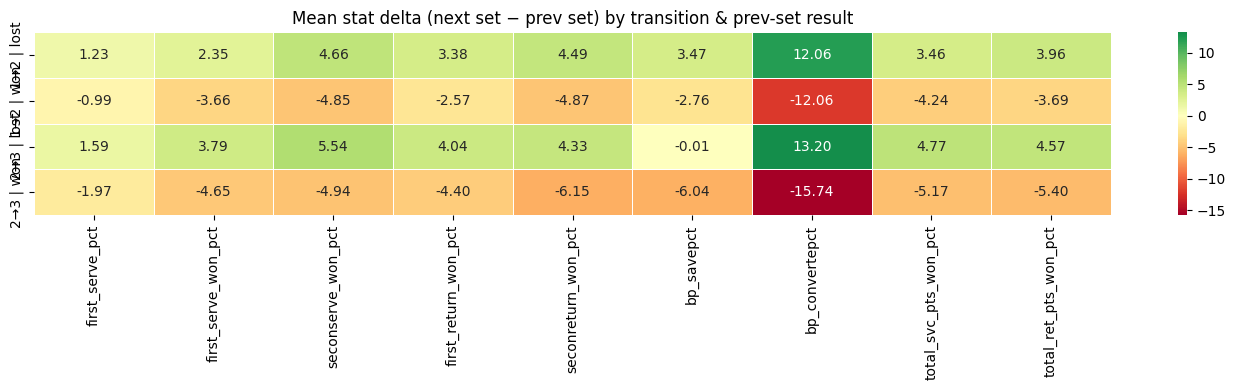

In [10]:
# ── Heatmap of mean deltas ────────────────────────────────────────────────────
heat_data = (
    transitions
    .groupby(["transition", "won_prev_set"])[DELTA_COLS]
    .mean()
    .round(2)
)
heat_data.index = [
    f"{t} | {'won' if w else 'lost'}"
    for t, w in heat_data.index
]
heat_data.columns = nice

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heat_data, annot=True, fmt=".2f", center=0,
    cmap="RdYlGn", linewidths=0.4, ax=ax
)
ax.set_title("Mean stat delta (next set − prev set) by transition & prev-set result")
plt.tight_layout()
plt.show()